                  Date  Temperature (°C)  Humidity (%)
0  2026-04-17 18:00:00             35.01            16
1  2026-04-17 21:00:00             33.16            17
2  2026-04-18 00:00:00             30.86            18
3  2026-04-18 03:00:00             36.19            13
4  2026-04-18 06:00:00             41.08            10


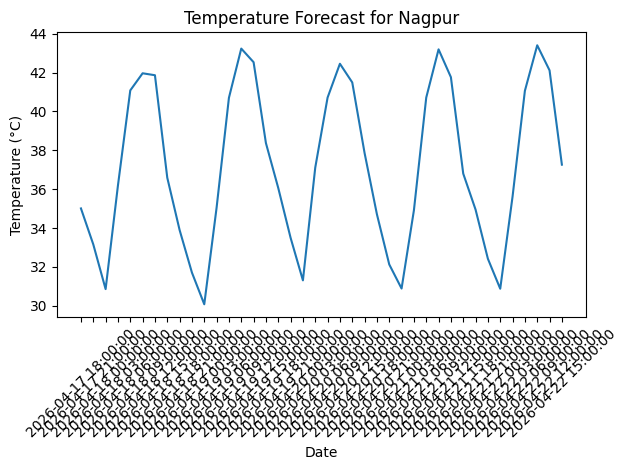

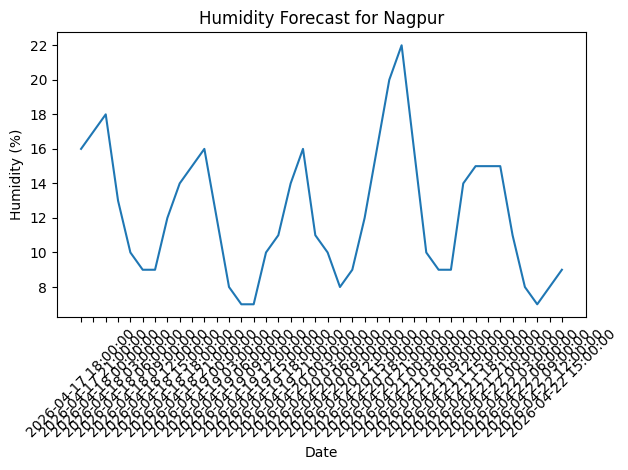

In [ ]:

!pip install requests

import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = "405a8dd14901a46a3d007414c831f323"
city = "Nagpur"
url = f"https://api.openweathermap.org/data/2.5/forecast?q={city}&appid={API_KEY}&units=metric"

response = requests.get(url)

if response.status_code != 200:
    print("Error:", response.json())
else:
    data = response.json()

    dates = []
    temps = []
    humidity = []

    for item in data['list']:
        dates.append(item['dt_txt'])
        temps.append(item['main']['temp'])
        humidity.append(item['main']['humidity'])

    df = pd.DataFrame({
        'Date': dates,
        'Temperature (°C)': temps,
        'Humidity (%)': humidity
    })

    print(df.head())

    plt.figure()
    plt.plot(df['Date'], df['Temperature (°C)'])
    plt.xticks(rotation=45)
    plt.title(f"Temperature Forecast for {city}")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.tight_layout()
    plt.show()
    plt.figure()
    plt.plot(df['Date'], df['Humidity (%)'])
    plt.xticks(rotation=45)
    plt.title(f"Humidity Forecast for {city}")
    plt.xlabel("Date")
    plt.ylabel("Humidity (%)")
    plt.tight_layout()
    plt.show()